<a href="https://colab.research.google.com/github/vinuthna01/speech_lab1/blob/main/Speech_Processing_Lab_2UPDATED(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASSIGNMENT-2


In [3]:
# Lab Assignment 2: Speech Sound Classification - Phoneme Extraction
# BLOCK 1: Install and Import Required Libraries

!pip install torch transformers librosa matplotlib numpy soundfile -q

import torch
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("✓ All libraries imported successfully")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"Librosa version: {librosa.__version__}")
print("=" * 60)

✓ All libraries imported successfully
PyTorch version: 2.10.0+cpu
Librosa version: 0.11.0


In [4]:
# BLOCK 2: Load the Speech Signal from Audio File

# Define the audio file path
audio_path = "/content/vinuthna_LAB1REC.wav"

# Load audio using librosa
audio_array, sample_rate = librosa.load(audio_path, sr=None)

print("=" * 60)
print("AUDIO FILE LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Original Sample Rate: {sample_rate} Hz")
print(f"Audio Shape: {audio_array.shape}")
print(f"Number of Samples: {len(audio_array)}")
print(f"Duration: {len(audio_array) / sample_rate:.2f} seconds")
print(f"Data type: {audio_array.dtype}")
print(f"Min amplitude: {audio_array.min():.4f}")
print(f"Max amplitude: {audio_array.max():.4f}")
print("=" * 60)

AUDIO FILE LOADED SUCCESSFULLY
Original Sample Rate: 48000 Hz
Audio Shape: (352256,)
Number of Samples: 352256
Duration: 7.34 seconds
Data type: float32
Min amplitude: -1.0000
Max amplitude: 0.9992


In [5]:
# BLOCK 3: Preprocess the Audio - Resample to 16kHz for Wav2Vec2

target_sample_rate = 16000

print("Starting preprocessing...")
print(f"Current sample rate: {sample_rate} Hz")
print(f"Target sample rate: {target_sample_rate} Hz")

if sample_rate != target_sample_rate:
    print(f"\nResampling from {sample_rate} Hz to {target_sample_rate} Hz...")
    audio_array = librosa.resample(
        audio_array,
        orig_sr=sample_rate,
        target_sr=target_sample_rate
    )
    sample_rate = target_sample_rate
    print("✓ Resampling complete")

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(f"Final Sample Rate: {sample_rate} Hz")
print(f"Final Audio Shape: {audio_array.shape}")
print(f"Final Number of Samples: {len(audio_array)}")
print(f"Final Duration: {len(audio_array) / sample_rate:.2f} seconds")
print("=" * 60)

Starting preprocessing...
Current sample rate: 48000 Hz
Target sample rate: 16000 Hz

Resampling from 48000 Hz to 16000 Hz...
✓ Resampling complete

PREPROCESSING COMPLETE
Final Sample Rate: 16000 Hz
Final Audio Shape: (117419,)
Final Number of Samples: 117419
Final Duration: 7.34 seconds


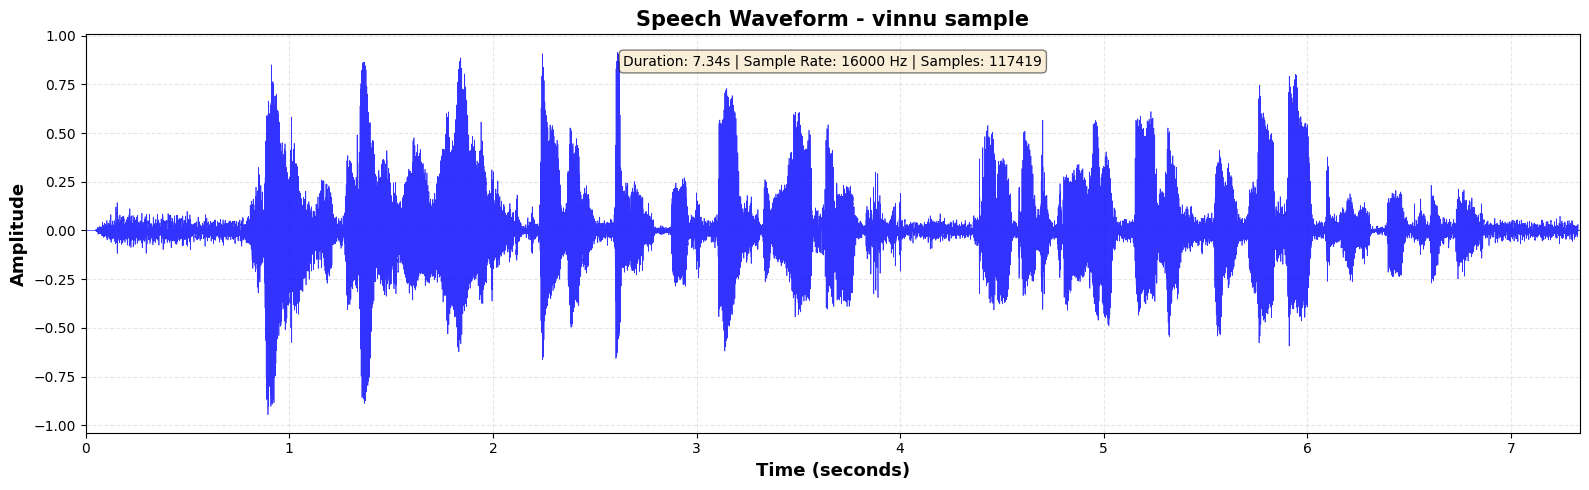

✓ Waveform visualization complete


In [7]:
# BLOCK 4: Visualize the Speech Waveform

plt.figure(figsize=(16, 5))

time_axis = np.linspace(0, len(audio_array) / sample_rate, len(audio_array))

plt.plot(time_axis, audio_array, linewidth=0.5, color='blue', alpha=0.8)
plt.xlabel('Time (seconds)', fontsize=13, fontweight='bold')
plt.ylabel('Amplitude', fontsize=13, fontweight='bold')
plt.title('Speech Waveform - vinnu sample', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, len(audio_array) / sample_rate)

stats_text = f'Duration: {len(audio_array) / sample_rate:.2f}s | Sample Rate: {sample_rate} Hz | Samples: {len(audio_array)}'
plt.text(0.5, 0.95, stats_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Waveform visualization complete")

In [8]:
# BLOCK 5: Load Wav2Vec2 Model for Speech Recognition

from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import torch

print("Loading Wav2Vec2 model...")

model_name = "facebook/wav2vec2-base-960h"

processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2ForCTC.from_pretrained(model_name)

model.eval()

print("=" * 60)
print("WAV2VEC2 MODEL LOADED SUCCESSFULLY")
print("=" * 60)


Loading Wav2Vec2 model...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


WAV2VEC2 MODEL LOADED SUCCESSFULLY


In [9]:
# BLOCK 6: Perform Speech Recognition

inputs = processor(
    audio_array,
    sampling_rate=sample_rate,
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    logits = model(inputs.input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]

print("=" * 60)
print("SPEECH RECOGNITION OUTPUT")
print("=" * 60)
print("Transcription:")
print(transcription)
print("=" * 60)

num_frames = logits.shape[1]
frame_duration = len(audio_array) / sample_rate / num_frames

print(f"Total frames: {num_frames}")
print(f"Frame duration: {frame_duration:.4f} seconds")


SPEECH RECOGNITION OUTPUT
Transcription:
HELLO THIS IS MY VOICE RECORDING FOR THE SPEECH CROSSING LABORATORY I AM TESTING THE RECORDING AND PLAY BACK OF THE SPEED SIGNAL
Total frames: 366
Frame duration: 0.0201 seconds


In [10]:
!pip install phonemizer
!apt-get install espeak-ng -y


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 24.8 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
The following NEW packages will be installed:
  espeak-ng espeak-ng-data libespeak-ng1 libpcaudio0 libsonic0
0 upgraded, 5 newly installed, 0 to remove and 2 not upgraded.
Need to get 4,526 kB of archives.
After this operation, 11.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libpcaudio0 amd64 1.1-6build2 [8,956 B]
Get:2 http://archive.ubuntu

In [11]:
# BLOCK 7: Convert Text to INDIVIDUAL PHONEMES (Correct API)

from phonemizer import phonemize
from phonemizer.separator import Separator

print("Converting recognized text to individual phonemes...\n")

separator = Separator(phone=" ", word=" | ", syllable="")

phoneme_text = phonemize(
    transcription,
    language='en-us',
    backend='espeak',
    strip=True,
    preserve_punctuation=False,
    with_stress=False,
    separator=separator
)

phoneme_list = phoneme_text.split()

print("=" * 60)
print("PHONEME EXTRACTION COMPLETE")
print("=" * 60)
print("Phoneme sequence:")
print(phoneme_text)
print(f"\nTotal phonemes: {len(phoneme_list)}")
print("=" * 60)


Converting recognized text to individual phonemes...

PHONEME EXTRACTION COMPLETE
Phoneme sequence:
h ə l oʊ | ð ɪ s | ɪ z | m aɪ | v ɔɪ s | ɹ ᵻ k oːɹ d ɪ ŋ | f ɚ ð ə | s p iː tʃ | k ɹ ɔ s ɪ ŋ | l æ b ɹ ə t ɔː ɹ i | aɪ ɐ m | t ɛ s t ɪ ŋ | ð ə | ɹ ᵻ k oːɹ d ɪ ŋ | æ n d | p l eɪ | b æ k | ʌ v ð ə | s p iː d | s ɪ ɡ n əl

Total phonemes: 103


In [12]:
# BLOCK 8: Estimate Phoneme Time Intervals

# Remove word boundary markers
phoneme_list = [p for p in phoneme_list if p != "|"]

total_duration = len(audio_array) / sample_rate
time_per_phoneme = total_duration / len(phoneme_list)

phoneme_segments = []

current_time = 0.0

for ph in phoneme_list:
    start_time = current_time
    end_time = current_time + time_per_phoneme
    phoneme_segments.append((ph, start_time, end_time))
    current_time = end_time

print("=" * 70)
print("PHONEME TIME INTERVALS")
print("=" * 70)
print("Phoneme | Start(s) | End(s) | Duration(s)")
print("-" * 70)

for ph, s, e in phoneme_segments[:15]:
    print(f"{ph:8} | {s:7.3f} | {e:7.3f} | {(e-s):7.3f}")

print("...")
print("=" * 70)


PHONEME TIME INTERVALS
Phoneme | Start(s) | End(s) | Duration(s)
----------------------------------------------------------------------
h        |   0.000 |   0.087 |   0.087
ə        |   0.087 |   0.175 |   0.087
l        |   0.175 |   0.262 |   0.087
oʊ       |   0.262 |   0.349 |   0.087
ð        |   0.349 |   0.437 |   0.087
ɪ        |   0.437 |   0.524 |   0.087
s        |   0.524 |   0.612 |   0.087
ɪ        |   0.612 |   0.699 |   0.087
z        |   0.699 |   0.786 |   0.087
m        |   0.786 |   0.874 |   0.087
aɪ       |   0.874 |   0.961 |   0.087
v        |   0.961 |   1.048 |   0.087
ɔɪ       |   1.048 |   1.136 |   0.087
s        |   1.136 |   1.223 |   0.087
ɹ        |   1.223 |   1.310 |   0.087
...


In [13]:
# BLOCK 9: Extract One Phoneme Waveform Segment

selected_index = 8   # you can change this

phoneme, start_time, end_time = phoneme_segments[selected_index]

start_sample = int(start_time * sample_rate)
end_sample = int(end_time * sample_rate)

phoneme_signal = audio_array[start_sample:end_sample]

print("=" * 60)
print("PHONEME SEGMENT EXTRACTION")
print("=" * 60)
print(f"Selected phoneme: {phoneme}")
print(f"Start time: {start_time:.3f} s")
print(f"End time: {end_time:.3f} s")
print(f"Duration: {(end_time - start_time):.3f} s")
print(f"Number of samples: {len(phoneme_signal)}")
print("=" * 60)


PHONEME SEGMENT EXTRACTION
Selected phoneme: z
Start time: 0.699 s
End time: 0.786 s
Duration: 0.087 s
Number of samples: 1398


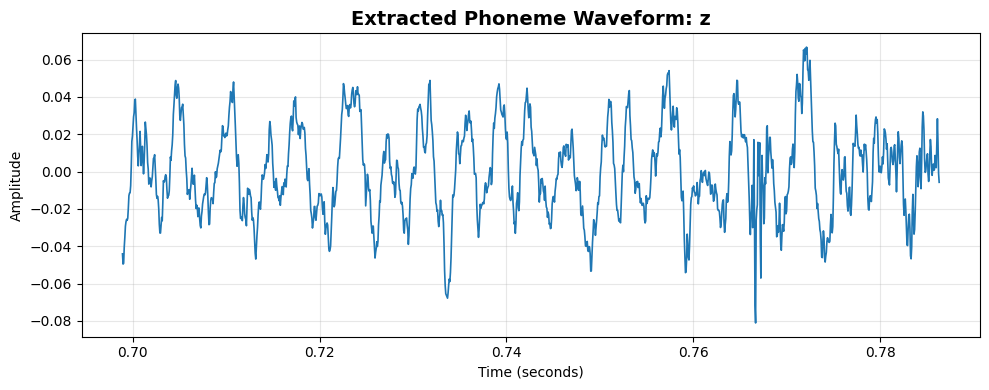

✓ Extracted phoneme waveform plotted successfully


In [14]:
# BLOCK 10: Visualize Extracted Phoneme Waveform

time_phoneme = np.linspace(start_time, end_time, len(phoneme_signal))

plt.figure(figsize=(10, 4))
plt.plot(time_phoneme, phoneme_signal, linewidth=1.2)

plt.title(f"Extracted Phoneme Waveform: {phoneme}", fontsize=14, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Extracted phoneme waveform plotted successfully")


In [15]:
# BLOCK 12: Improved Sound Source Inference (Phonetically Correct)

vowel_symbols = ['a', 'ɑ', 'ɪ', 'i', 'e', 'ɛ', 'æ', 'ʌ', 'ə', 'o', 'u', 'ʊ', 'ɔ']

voiced_consonants = ['m', 'n', 'ŋ', 'l', 'r', 'ɹ', 'ɾ', 'v', 'z', 'ʒ', 'ð', 'b', 'd', 'g']

unvoiced_consonants = ['f', 's', 'ʃ', 'θ', 'h']

plosives = ['p', 't', 'k', 'b', 'd', 'g']

print("=" * 80)
print("NATURE OF SOUND SOURCE FOR EACH PHONEME")
print("=" * 80)
print("Phoneme | Sound Source")
print("-" * 80)

for ph in phoneme_list:

    # Plosives
    if any(p == ph for p in plosives):
        source = "Plosive (closure followed by burst)"

    # Affricates
    elif ph == 'dʒ':
        source = "Voiced affricate (stop + frication)"
    elif ph == 'tʃ':
        source = "Unvoiced affricate (stop + frication)"

    # Contains vowel → voiced
    elif any(v in ph for v in vowel_symbols):
        source = "Voiced sound (vocal fold vibration)"

    # Voiced consonants
    elif any(c in ph for c in voiced_consonants):
        source = "Voiced sound (vocal fold vibration)"

    # Unvoiced consonants
    elif any(c in ph for c in unvoiced_consonants):
        source = "Unvoiced sound (turbulent airflow)"

    else:
        source = "Transitional / coarticulated sound"

    print(f"{ph:8} | {source}")

print("=" * 80)


NATURE OF SOUND SOURCE FOR EACH PHONEME
Phoneme | Sound Source
--------------------------------------------------------------------------------
h        | Unvoiced sound (turbulent airflow)
ə        | Voiced sound (vocal fold vibration)
l        | Voiced sound (vocal fold vibration)
oʊ       | Voiced sound (vocal fold vibration)
ð        | Voiced sound (vocal fold vibration)
ɪ        | Voiced sound (vocal fold vibration)
s        | Unvoiced sound (turbulent airflow)
ɪ        | Voiced sound (vocal fold vibration)
z        | Voiced sound (vocal fold vibration)
m        | Voiced sound (vocal fold vibration)
aɪ       | Voiced sound (vocal fold vibration)
v        | Voiced sound (vocal fold vibration)
ɔɪ       | Voiced sound (vocal fold vibration)
s        | Unvoiced sound (turbulent airflow)
ɹ        | Voiced sound (vocal fold vibration)
ᵻ        | Transitional / coarticulated sound
k        | Plosive (closure followed by burst)
oːɹ      | Voiced sound (vocal fold vibration)
d        | Plo